# Initialize Networks

## Purpose: 

* Load multiple sources of data
    * Sunny's differential expression 
    * Transcription factor data from `AnimalTFDB v4.0`
* Subset all parameter combinations to: 
    * Differentially Expressed Genes 
    * Transcription Factors Only
* Look at `SOX4` Overrepresentation and Plots
* Output the resulting `NetworkX` Directed Graphs as pickled objects

In [1]:
import pandas as pd
pd.set_option('display.max_rows', 1000000)
pd.set_option('display.max_columns', 1000000)
pd.set_option('display.width', 10000000)

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import glob, randomcolor, pickle, scipy
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import seaborn as sns

## Thresholds

In [2]:
# thresholds for relative scores for each transcription factor used 
# NOTE: 900 = 90th percentile and so on
relative_threshold = [900, 950, 990]

# thresholds for how far upstream of TSS was used
upstream_thresholds = ["750", "2500", "5000"]

## Load Data

In [3]:
# load predicted mouse transcription factors

mouse_tfs = pd.read_csv("../../../../inputs/mouse_tfs/Mus_musculus_TF.txt", sep="\t")
mouse_tfs = mouse_tfs.set_index("Ensembl")

mouse_tfs.head()

,Species,Symbol,Family,Protein,Entrez_ID
Ensembl,,,,,
ENSMUSG00000063804,Mus_musculus,Lin28b,CSD,ENSMUSP00000078361.7;,380669.0
ENSMUSG00000000093,Mus_musculus,Tbx2,T-box,ENSMUSP00000000095.7;,21385.0
ENSMUSG00000042508,Mus_musculus,Dmtf1,MYB,ENSMUSP00000071815.6;ENSMUSP00000139361.2;ENSM...,23857.0
ENSMUSG00000021604,Mus_musculus,Irx4,Homeobox,ENSMUSP00000134738.2;ENSMUSP00000022095.8;,50916.0
ENSMUSG00000003184,Mus_musculus,Irf3,IRF,ENSMUSP00000146773.2;ENSMUSP00000146383.2;ENSM...,54131.0


In [4]:
# load differential expression data from Sunny 

sunny_diff_exp = pd.read_excel("../../../../inputs/sunny_differential_analysis/mRNA-level-E9-5_Rbfox2_KO-Het.xlsx")
sunny_diff_exp.head()

,ENSMUSG,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_id
0,ENSMUSG00000017950,219.709303,-4.693934,0.867171,-5.412926,6.200306e-08,2.998404e-05,Hnf4a
1,ENSMUSG00000028357,70.833068,-4.668388,0.678707,-6.878359,6.054593e-12,8.783817e-09,Kif12
2,ENSMUSG00000040891,83.085759,-4.616412,0.574760,-8.031891,9.598124e-16,2.262758e-12,Foxa3
3,ENSMUSG00000017344,325.121362,-4.357324,1.097967,-3.968539,7.231450e-05,8.265767e-03,Vtn
4,ENSMUSG00000020609,246.446133,-4.086230,1.030140,-3.966674,7.288267e-05,8.280525e-03,Apob


In [5]:
# load all of the transcript to gene annotation tables

annotation_tables = {}

for file in sorted(glob.glob("../../5_transcripts_to_genes/outputs/*")): 
    
    annotation_tables[file.split("/")[-1].split(".tsv")[0]] = pd.read_csv(
        file, 
        sep="\t",
        compression="gzip"
    )

In [6]:
annotation_tables.keys()

dict_keys(['MA0052.4.upstream_2500', 'MA0052.4.upstream_5000', 'MA0052.4.upstream_750', 'MA0058.3.upstream_2500', 'MA0058.3.upstream_5000', 'MA0058.3.upstream_750', 'MA0072.1.upstream_2500', 'MA0072.1.upstream_5000', 'MA0072.1.upstream_750', 'MA0073.1.upstream_2500', 'MA0073.1.upstream_5000', 'MA0073.1.upstream_750', 'MA0076.2.upstream_2500', 'MA0076.2.upstream_5000', 'MA0076.2.upstream_750', 'MA0161.2.upstream_2500', 'MA0161.2.upstream_5000', 'MA0161.2.upstream_750', 'MA0489.2.upstream_2500', 'MA0489.2.upstream_5000', 'MA0489.2.upstream_750', 'MA0506.2.upstream_2500', 'MA0506.2.upstream_5000', 'MA0506.2.upstream_750', 'MA0520.1.upstream_2500', 'MA0520.1.upstream_5000', 'MA0520.1.upstream_750', 'MA0523.1.upstream_2500', 'MA0523.1.upstream_5000', 'MA0523.1.upstream_750', 'MA0592.3.upstream_2500', 'MA0592.3.upstream_5000', 'MA0592.3.upstream_750', 'MA0677.1.upstream_2500', 'MA0677.1.upstream_5000', 'MA0677.1.upstream_750', 'MA0739.1.upstream_2500', 'MA0739.1.upstream_5000', 'MA0739.1.ups

#### Remove rows that are not annotated to any genes

In [7]:
for key in annotation_tables:
    tmp = annotation_tables[key].dropna(axis=0)
    annotation_tables[key] = tmp 
    
    tmp.index.size
    

1736975

2702262

714857

2789623

4055158

...

539458

135938

1363366

2039472

635099

## Differential Expression Volcano Plot



In [8]:
sunny_diff_exp.sort_values(by=["log2FoldChange"]).head()

,ENSMUSG,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_id
0,ENSMUSG00000017950,219.709303,-4.693934,0.867171,-5.412926,6.200306e-08,2.998404e-05,Hnf4a
1,ENSMUSG00000028357,70.833068,-4.668388,0.678707,-6.878359,6.054593e-12,8.783817e-09,Kif12
2,ENSMUSG00000040891,83.085759,-4.616412,0.574760,-8.031891,9.598124e-16,2.262758e-12,Foxa3
3,ENSMUSG00000017344,325.121362,-4.357324,1.097967,-3.968539,7.231450e-05,8.265767e-03,Vtn
4,ENSMUSG00000020609,246.446133,-4.086230,1.030140,-3.966674,7.288267e-05,8.280525e-03,Apob


In [9]:
sunny_diff_exp.sort_values(by=["padj"]).head()

,ENSMUSG,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_id
327,ENSMUSG00000034009,412.067179,2.811033,0.243924,11.524228,9.960137e-31,1.878482e-26,Rxfp1
20,ENSMUSG00000042453,4135.717257,-2.232809,0.212768,-10.494104,9.194560e-26,8.670470e-22,Reln
316,ENSMUSG00000029019,9698.209515,2.139324,0.209991,10.187674,2.250844e-24,1.415031e-20,Nppb
62,ENSMUSG00000033565,15194.864445,-0.994187,0.100046,-9.937295,2.865000e-23,1.350848e-19,Rbfox2
305,ENSMUSG00000019997,3414.818470,1.729922,0.187888,9.207206,3.347254e-20,1.262584e-16,Ctgf


<Figure size 1280x960 with 0 Axes>

Text(0.5, 1.0, "Volcano Plot of Sunny's Differential Expression Analysis")

Text(0, 0.5, '-log10(Adjusted P-Value)')

Text(0.5, 0, 'log2(Fold-Change)')

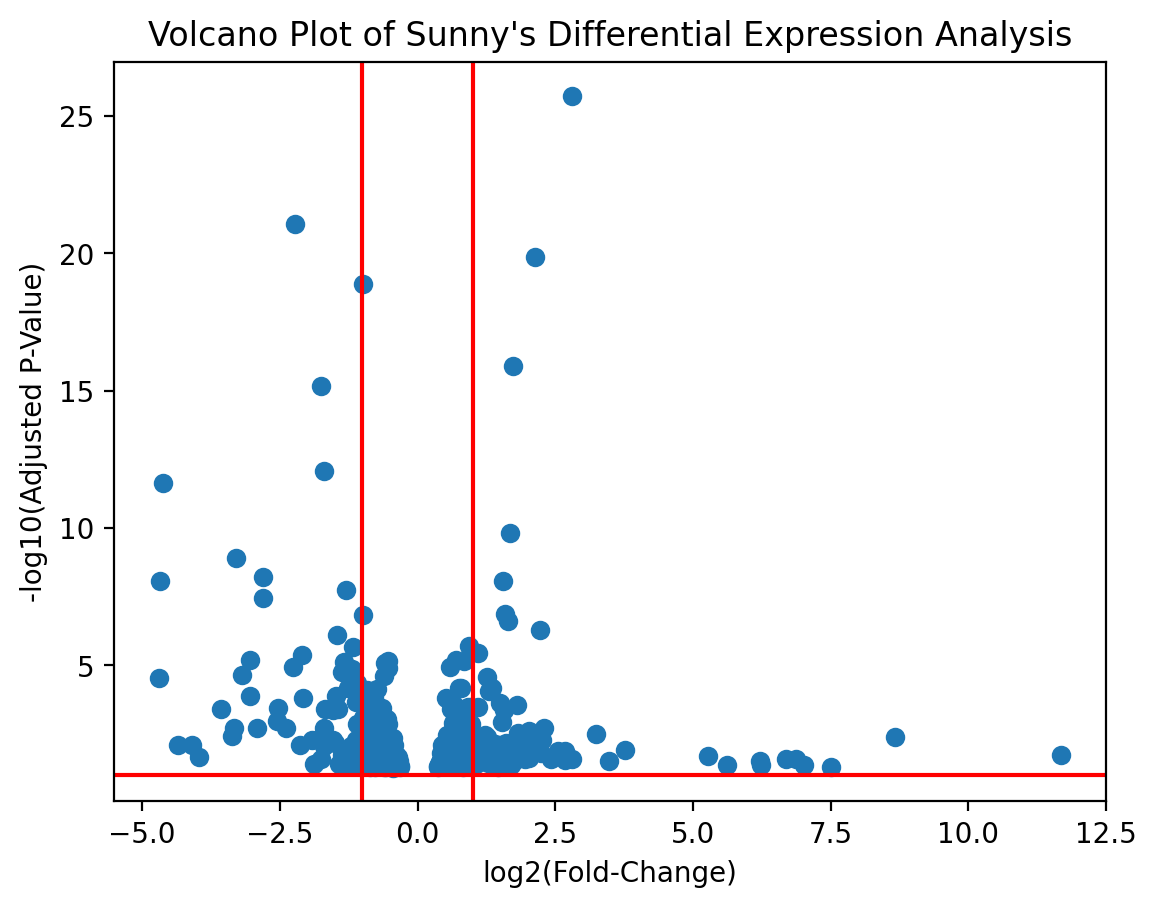

In [10]:
plt.figure(dpi=200)

plt.title("Volcano Plot of Sunny's Differential Expression Analysis")
plt.scatter(x=sunny_diff_exp["log2FoldChange"], y=-np.log10(sunny_diff_exp["padj"]))

plt.ylabel("-log10(Adjusted P-Value)")
plt.xlabel("log2(Fold-Change)")

plt.axvline(1, color="red", label="1")
plt.axvline(-1, color="red", label="-1")

plt.axhline(1, color='red', label="1")

#### Save differential expression `ENSEMBL` IDs

In [11]:
diff_gene_ids = sunny_diff_exp["ENSMUSG"].tolist()

print(diff_gene_ids,end="\t")

['ENSMUSG00000017950', 'ENSMUSG00000028357', 'ENSMUSG00000040891', 'ENSMUSG00000017344', 'ENSMUSG00000020609', 'ENSMUSG00000032083', 'ENSMUSG00000042448', 'ENSMUSG00000071551', 'ENSMUSG00000074768', 'ENSMUSG00000045518', 'ENSMUSG00000019368', 'ENSMUSG00000038700', 'ENSMUSG00000029195', 'ENSMUSG00000044254', 'ENSMUSG00000026398', 'ENSMUSG00000005320', 'ENSMUSG00000020679', 'ENSMUSG00000029556', 'ENSMUSG00000037025', 'ENSMUSG00000005681', 'ENSMUSG00000042453', 'ENSMUSG00000024391', 'ENSMUSG00000045991', 'ENSMUSG00000030088', 'ENSMUSG00000026227', 'ENSMUSG00000026934', 'ENSMUSG00000073409', 'ENSMUSG00000032796', 'ENSMUSG00000031654', 'ENSMUSG00000031883', 'ENSMUSG00000064225', 'ENSMUSG00000028373', 'ENSMUSG00000055409', 'ENSMUSG00000038692', 'ENSMUSG00000021209', 'ENSMUSG00000034450', 'ENSMUSG00000025196', 'ENSMUSG00000079654', 'ENSMUSG00000024907', 'ENSMUSG00000048126', 'ENSMUSG00000020080', 'ENSMUSG00000102692', 'ENSMUSG00000074575', 'ENSMUSG00000018822', 'ENSMUSG00000024986', 'ENSMUSG0

## Construct Edgelist

Need to make sure that transcription factor names coming from Sunny's list actually have `GENCODE` IDs. 

This is because we want to avoid situations where the TF in question is named something else in `GENCODE` so we're missing links. 

In [12]:
for key in annotation_tables: 
    # don't get repeat entries due to different thresholds used for annotation
    if "5000" in key: 
        annotation_tables[key]["1"].unique()

array(['MEF2A'], dtype=object)

array(['MAX'], dtype=object)

array(['RORA'], dtype=object)

array(['RREB1'], dtype=object)

array(['ELK4'], dtype=object)

...

array(['NR4A1'], dtype=object)

array(['PBX3'], dtype=object)

array(['MAZ'], dtype=object)

array(['NR6A1'], dtype=object)

array(['SMAD5'], dtype=object)

The above `TFs` besides `RORA` are part of `GENCODE`. 

`RORA` is from `RefSeq`. 

In [13]:
individual_edge_lists = {}

for key in annotation_tables:
    
    key 
    
    # rename columns
    tmp = annotation_tables[key][["1", "Gene name", "Gene stable ID", "2"]].rename(
        columns={"1":"TF", "Gene name":"Target", "Gene stable ID": "Target ID", "2": "Relative Score"}
    )

    # make gene names lowercase to avoid weird issues where there are duplicate nodes (due to capitalization issues)
    tmp["TF"] = tmp["TF"].str.lower()
    tmp["Target"] =  tmp["Target"].str.lower()
    
    # for each threshold in relative scoring
    for threshold in relative_threshold: 
        
        # subset relative scores for thresholds
        tmp = tmp[tmp["Relative Score"]>threshold]
        
        # create key for edge list 
        edge_list_key = "{}_relative_score_percentile_{}".format(key, threshold)
        
        # get the unique TF-target pairs 
        individual_edge_lists[edge_list_key] = tmp[["TF", "Target", "Target ID"]].drop_duplicates()
    

'MA0052.4.upstream_2500'

'MA0052.4.upstream_5000'

'MA0052.4.upstream_750'

'MA0058.3.upstream_2500'

'MA0058.3.upstream_5000'

...

'MA1541.1.upstream_5000'

'MA1541.1.upstream_750'

'MA1557.1.upstream_2500'

'MA1557.1.upstream_5000'

'MA1557.1.upstream_750'

Concatenate all lists that have the same upstream parameter and relative score threshold

In [14]:
final_edge_lists = {}

for score_threshold in relative_threshold: 
    for upstream_threshold in upstream_thresholds:
        edge_list_key = "upstream_{}_score_{}".format(upstream_threshold, score_threshold)
        final_edge_lists[edge_list_key] = []
        
        for key in individual_edge_lists: 
            if str(score_threshold) in key and str(upstream_threshold) in key: 
                final_edge_lists[edge_list_key].append(individual_edge_lists[key])
    
# concatenate all the pandas dataframes 

for key in final_edge_lists:
    key
    final_edge_lists[key] = pd.concat(final_edge_lists[key])
    final_edge_lists[key] = final_edge_lists[key].set_index("Target ID")
    final_edge_lists[key].index.size


'upstream_750_score_900'

166801

'upstream_2500_score_900'

243534

'upstream_5000_score_900'

...

8214

'upstream_2500_score_990'

15820

'upstream_5000_score_990'

23609

Check number of gene targets per combination of parameters

In [15]:
unique_gene_numbers = []

for key in final_edge_lists: 
    key
    final_edge_lists[key]["Target"].unique().size
    unique_gene_numbers.append(final_edge_lists[key]["Target"].unique().size)
    
unique_gene_numbers

'upstream_750_score_900'

19471

'upstream_2500_score_900'

19528

'upstream_5000_score_900'

...

'upstream_2500_score_990'

9789

'upstream_5000_score_990'

12467

[19471, 19528, 19583, 18004, 19345, 19541, 6232, 9789, 12467]

<Figure size 1280x960 with 0 Axes>

Text(0.5, 0, 'Upstream of TSS by')

Text(0, 0.5, 'Number of Unique Protein-coding Genes')

([<matplotlib.axis.XTick at 0x7fe452dde490>,
 [Text(0.25, 0, '750'), Text(1.25, 0, '2500'), Text(2.25, 0, '5000')])

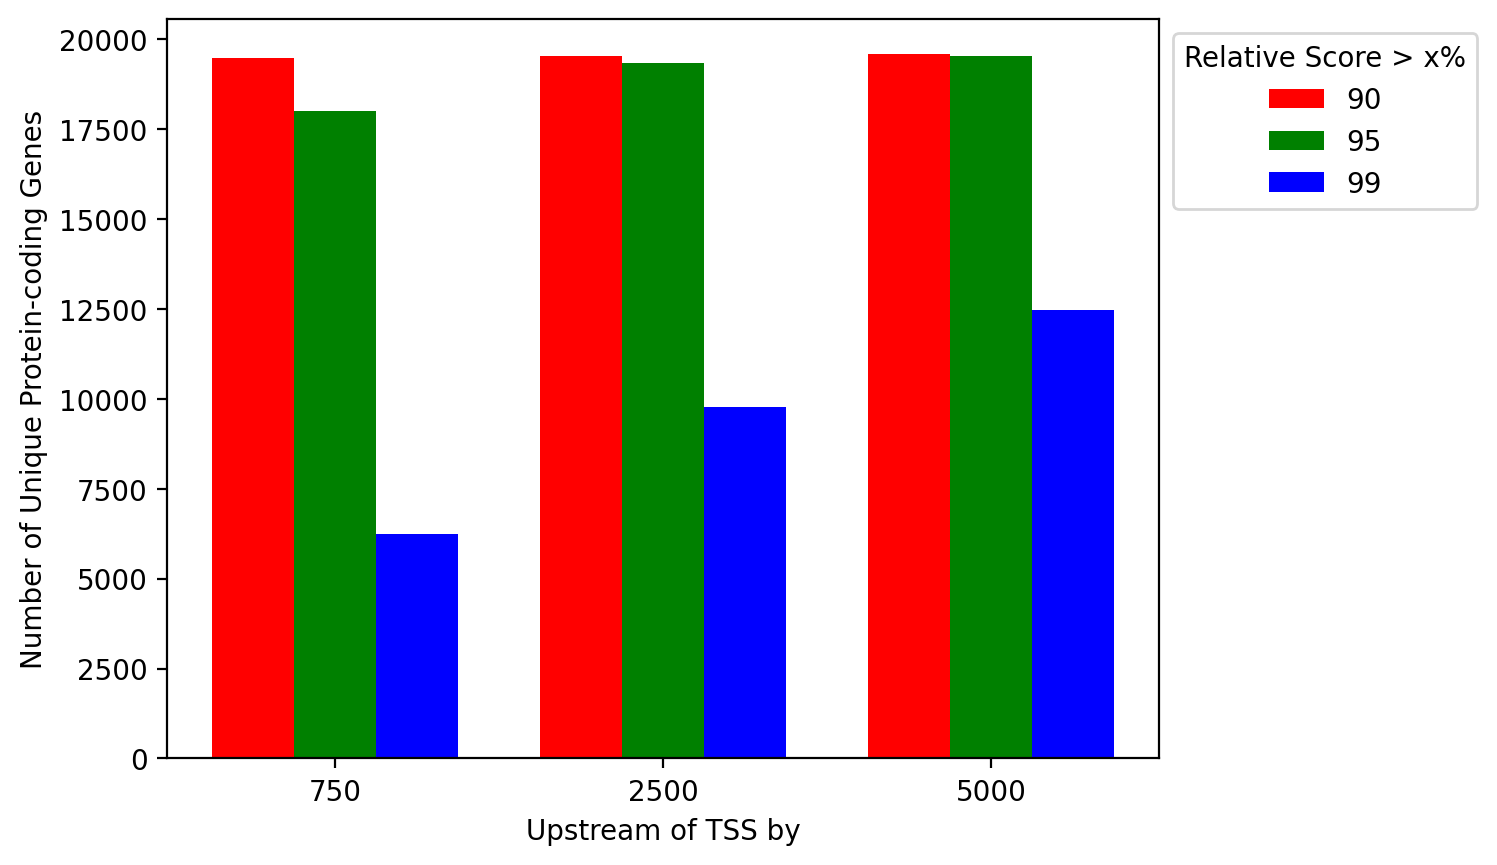

In [16]:
plt.figure(dpi=200)

N = 3
ind = np.arange(N) 
width = 0.25
  
bar1 = plt.bar(ind, unique_gene_numbers[0:3], width, color = 'r')
bar2 = plt.bar(ind+width, unique_gene_numbers[3:6], width, color='g')
bar3 = plt.bar(ind+width*2, unique_gene_numbers[6:9], width, color = 'b')
  
plt.xlabel("Upstream of TSS by")
plt.ylabel('Number of Unique Protein-coding Genes')
  
plt.xticks(ind+width,["750", "2500", "5000"])
plt.legend( (bar1, bar2, bar3), ('90', '95', '99'), title="Relative Score > x%", bbox_to_anchor=(1,1))
plt.show()

## Subset to Transcription Factors & Initialize those Networks

In [17]:
mouse_tfs.head()

,Species,Symbol,Family,Protein,Entrez_ID
Ensembl,,,,,
ENSMUSG00000063804,Mus_musculus,Lin28b,CSD,ENSMUSP00000078361.7;,380669.0
ENSMUSG00000000093,Mus_musculus,Tbx2,T-box,ENSMUSP00000000095.7;,21385.0
ENSMUSG00000042508,Mus_musculus,Dmtf1,MYB,ENSMUSP00000071815.6;ENSMUSP00000139361.2;ENSM...,23857.0
ENSMUSG00000021604,Mus_musculus,Irx4,Homeobox,ENSMUSP00000134738.2;ENSMUSP00000022095.8;,50916.0
ENSMUSG00000003184,Mus_musculus,Irf3,IRF,ENSMUSP00000146773.2;ENSMUSP00000146383.2;ENSM...,54131.0


In [18]:
joined_tf_tf_edge_lists = {}

# join the edge lists for each parameter combination with the TF table above
for key in final_edge_lists: 
    
    tmp =  final_edge_lists[key].join(mouse_tfs, how="inner")
    
    joined_tf_tf_edge_lists[key] =tmp 
    
    tmp.index.unique().size
    tmp.head()
    

1540

,TF,Target,Species,Symbol,Family,Protein,Entrez_ID
Target ID,,,,,,,
ENSMUSG00000000078,mef2a,klf6,Mus_musculus,Klf6,zf-C2H2,ENSMUSP00000000080.7;,23849.0
ENSMUSG00000000247,mef2a,lhx2,Mus_musculus,Lhx2,Homeobox,ENSMUSP00000114797.3;ENSMUSP00000000253.6;,16870.0
ENSMUSG00000000282,mef2a,mnt,Mus_musculus,Mnt,bHLH,ENSMUSP00000118435.2;ENSMUSP00000000291.3;,17428.0
ENSMUSG00000000439,mef2a,mkrn2,Mus_musculus,Mkrn2,zf-CCCH,ENSMUSP00000000449.8;,67027.0
ENSMUSG00000000567,mef2a,sox9,Mus_musculus,Sox9,HMG,ENSMUSP00000000579.3;,20682.0


1548

,TF,Target,Species,Symbol,Family,Protein,Entrez_ID
Target ID,,,,,,,
ENSMUSG00000000078,mef2a,klf6,Mus_musculus,Klf6,zf-C2H2,ENSMUSP00000000080.7;,23849.0
ENSMUSG00000000247,mef2a,lhx2,Mus_musculus,Lhx2,Homeobox,ENSMUSP00000114797.3;ENSMUSP00000000253.6;,16870.0
ENSMUSG00000000282,mef2a,mnt,Mus_musculus,Mnt,bHLH,ENSMUSP00000118435.2;ENSMUSP00000000291.3;,17428.0
ENSMUSG00000000439,mef2a,mkrn2,Mus_musculus,Mkrn2,zf-CCCH,ENSMUSP00000000449.8;,67027.0
ENSMUSG00000000567,mef2a,sox9,Mus_musculus,Sox9,HMG,ENSMUSP00000000579.3;,20682.0


1550

...

,TF,Target,Species,Symbol,Family,Protein,Entrez_ID
Target ID,,,,,,,
ENSMUSG00000030103,mef2a,bhlhe40,Mus_musculus,Bhlhe40,bHLH,ENSMUSP00000032194.5;ENSMUSP00000132157.2;,20893.0
ENSMUSG00000022306,mef2a,zfpm2,Mus_musculus,Zfpm2,zf-C2H2,ENSMUSP00000155094.2;ENSMUSP00000051335.5;,22762.0
ENSMUSG00000000282,max,mnt,Mus_musculus,Mnt,bHLH,ENSMUSP00000118435.2;ENSMUSP00000000291.3;,17428.0
ENSMUSG00000000861,max,bcl11a,Mus_musculus,Bcl11a,zf-C2H2,ENSMUSP00000105140.2;ENSMUSP00000000881.7;,14025.0
ENSMUSG00000024140,max,epas1,Mus_musculus,Epas1,Others,NaN,13819.0


804

,TF,Target,Species,Symbol,Family,Protein,Entrez_ID
Target ID,,,,,,,
ENSMUSG00000030103,mef2a,bhlhe40,Mus_musculus,Bhlhe40,bHLH,ENSMUSP00000032194.5;ENSMUSP00000132157.2;,20893.0
ENSMUSG00000038056,mef2a,kmt2c,Mus_musculus,Kmt2c,HMG,ENSMUSP00000043874.8;ENSMUSP00000134442.2;,231051.0
ENSMUSG00000022306,mef2a,zfpm2,Mus_musculus,Zfpm2,zf-C2H2,ENSMUSP00000155094.2;ENSMUSP00000051335.5;,22762.0
ENSMUSG00000017491,mef2a,rarb,Mus_musculus,Rarb,THR-like,ENSMUSP00000153178.2;ENSMUSP00000152980.2;ENSM...,218772.0
ENSMUSG00000071769,mef2a,rhox3h,Mus_musculus,Rhox3h,Homeobox,ENSMUSP00000094196.5;,434758.0


1002

,TF,Target,Species,Symbol,Family,Protein,Entrez_ID
Target ID,,,,,,,
ENSMUSG00000030103,mef2a,bhlhe40,Mus_musculus,Bhlhe40,bHLH,ENSMUSP00000032194.5;ENSMUSP00000132157.2;,20893.0
ENSMUSG00000035158,mef2a,mitf,Mus_musculus,Mitf,bHLH,ENSMUSP00000144988.2;ENSMUSP00000044459.7;ENSM...,17342.0
ENSMUSG00000038056,mef2a,kmt2c,Mus_musculus,Kmt2c,HMG,ENSMUSP00000043874.8;ENSMUSP00000134442.2;,231051.0
ENSMUSG00000022306,mef2a,zfpm2,Mus_musculus,Zfpm2,zf-C2H2,ENSMUSP00000155094.2;ENSMUSP00000051335.5;,22762.0
ENSMUSG00000017491,mef2a,rarb,Mus_musculus,Rarb,THR-like,ENSMUSP00000153178.2;ENSMUSP00000152980.2;ENSM...,218772.0


In [19]:
tf_tf_networks = {}

# create directed NetworkX graph clearly specifying target and source
for key in joined_tf_tf_edge_lists: 
    tmp = nx.from_pandas_edgelist(joined_tf_tf_edge_lists[key], source="TF", target="Target", create_using=nx.DiGraph())
    tf_tf_networks[key] = tmp
    
#     plt.figure(dpi=300)
#     plt.title(key)
#     nx.draw(tmp, pos= nx.spring_layout(tmp))
#     plt.show()

## Subset to Differentially Expressed Genes & Initialize those Networks

In [20]:
joined_final_edge_lists = {}

# join each edge list with differential gene ids to subset
for key in final_edge_lists: 
    key
    
    tmp = final_edge_lists[key].join(pd.DataFrame(diff_gene_ids).set_index(0), how="inner")
    
    joined_final_edge_lists[key] = tmp 
    
    tmp.index.size

'upstream_750_score_900'

3017

'upstream_2500_score_900'

4145

'upstream_5000_score_900'

...

179

'upstream_2500_score_990'

346

'upstream_5000_score_990'

518

#### Visualize % of Differentially Expressed Genes that Are Predicted as TF Targets

This is based on `JASPAR`. 

As well, this is meant to be across all parameter combinations

'upstream_750_score_900'

311

'upstream_2500_score_900'

312

'upstream_5000_score_900'

...

238

<Figure size 1280x960 with 0 Axes>

Text(0.5, 0, 'Upstream of TSS by')

Text(0, 0.5, '% of Diff. Expression Genes as TF Targets ')

([<matplotlib.axis.XTick at 0x7fe49a39c750>,
 [Text(0.25, 0, '750'), Text(1.25, 0, '2500'), Text(2.25, 0, '5000')])

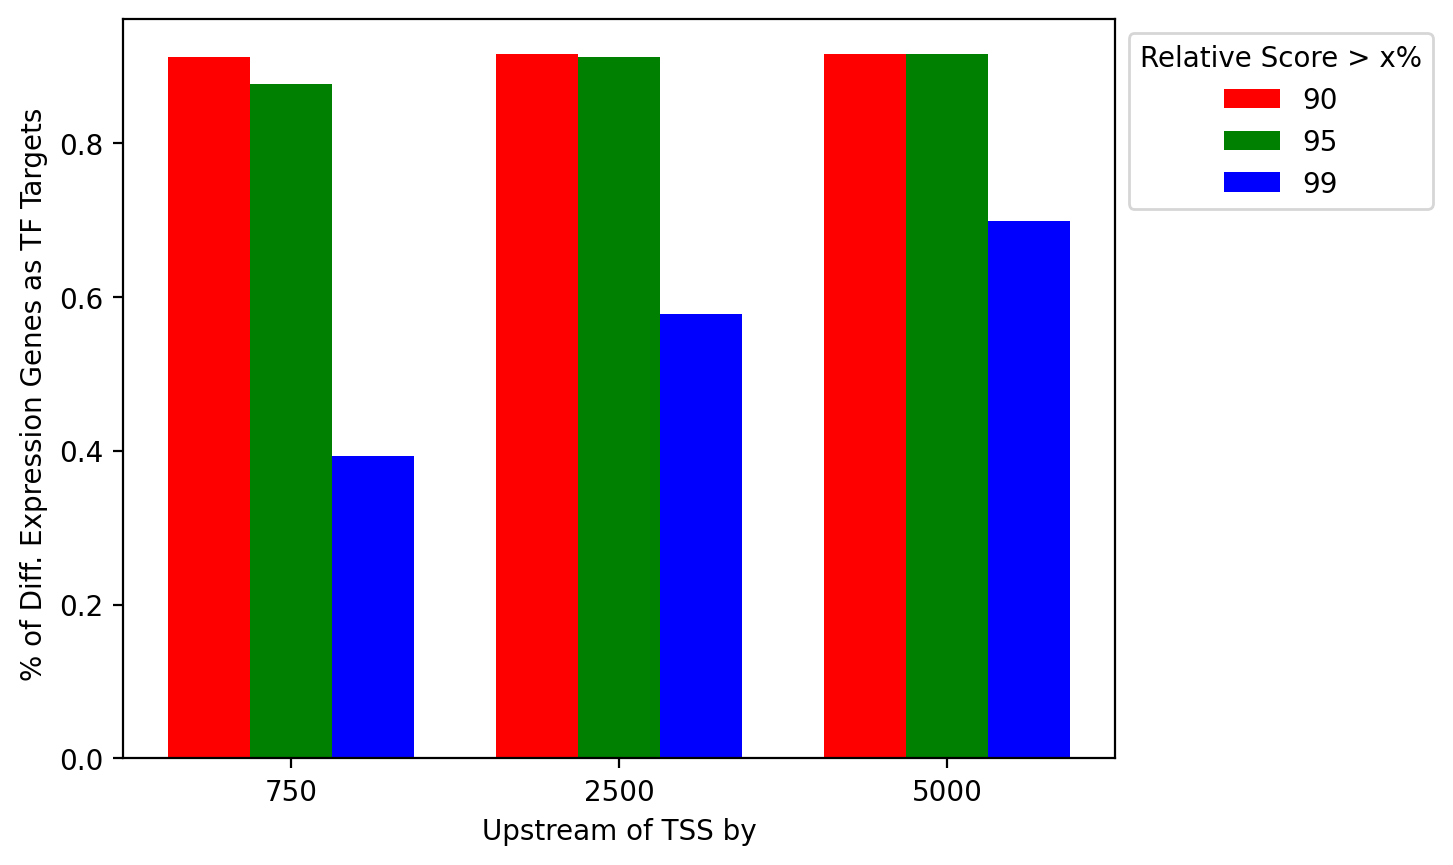

In [21]:
unique_gene_numbers = []

for key in joined_final_edge_lists: 
    key
    joined_final_edge_lists[key]["Target"].unique().size
    unique_gene_numbers.append((joined_final_edge_lists[key]["Target"].unique().size)/len(diff_gene_ids))
    

plt.figure(dpi=200)

N = 3
ind = np.arange(N) 
width = 0.25
  
bar1 = plt.bar(ind, unique_gene_numbers[0:3], width, color = 'r')
bar2 = plt.bar(ind+width, unique_gene_numbers[3:6], width, color='g')
bar3 = plt.bar(ind+width*2, unique_gene_numbers[6:9], width, color = 'b')
  
plt.xlabel("Upstream of TSS by")
plt.ylabel('% of Diff. Expression Genes as TF Targets ')
  
plt.xticks(ind+width,["750", "2500", "5000"])
plt.legend( (bar1, bar2, bar3), ('90', '95', '99'), title="Relative Score > x%", bbox_to_anchor=(1,1))
plt.show()

In [22]:
for key in joined_final_edge_lists: 
    key
    joined_final_edge_lists[key]["TF"].value_counts().head()

'upstream_750_score_900'

TF
sox4     284
hic1     271
maz      259
elk4     210
nr2f2    190
Name: count, dtype: int64

'upstream_2500_score_900'

TF
sox4      309
hic1      307
maz       289
hmbox1    268
elk4      259
Name: count, dtype: int64

'upstream_5000_score_900'

...

TF
maz      74
sox4     35
jun      22
hic1     12
nr2f2    12
Name: count, dtype: int64

'upstream_2500_score_990'

TF
maz     110
sox4     62
jun      52
hic1     27
nfic     24
Name: count, dtype: int64

'upstream_5000_score_990'

TF
maz      140
sox4      81
jun       80
hic1      45
nr2f2     43
Name: count, dtype: int64

### Plot number of differentially expressed genes each `TF` binds to based on `JASPAR` predictions

In [23]:
concat_list = []

for key in joined_final_edge_lists: 
    tmp = joined_final_edge_lists[key].groupby("TF").count()
    tmp["Parameter Combination"] = "-".join([key.split("_")[1], key.split("_")[3]])
    
    concat_list.append(tmp)

tf_num_diff_genes_targetting = pd.concat(concat_list)

tf_num_diff_genes_targetting.head()


,Target,Parameter Combination
TF,,
creb3l1,1,750-900
elk4,210,750-900
esrra,86,750-900
gata6,125,750-900
hic1,271,750-900


In [24]:
combination_order = pd.api.types.CategoricalDtype(
    [
        "750-900",
        "750-950",
        "750-990",
        "2500-900",
        "2500-950",
        "2500-990",
        "5000-900",
        "5000-950",
        "5000-990"
    ], 
    ordered=True
)

combination_order

tf_num_diff_genes_targetting["Parameter Combination"] = tf_num_diff_genes_targetting["Parameter Combination"].astype(combination_order)

tf_num_diff_genes_targetting.dtypes

tf_num_diff_genes_targetting = tf_num_diff_genes_targetting.sort_values("Parameter Combination")

tf_num_diff_genes_targetting["Relative Score"] = tf_num_diff_genes_targetting["Parameter Combination"].str.split("-").str[1]

upstream_param_col = []
for combo in tf_num_diff_genes_targetting["Parameter Combination"].to_list(): 
    upstream_param_col.append(
        "[-{}, +250]".format(
            combo.split("-")[0]
        )
    )

tf_num_diff_genes_targetting["TSS Window"] = upstream_param_col    


tf_num_diff_genes_targetting.head()

CategoricalDtype(categories=['750-900', '750-950', '750-990', '2500-900', '2500-950', '2500-990', '5000-900', '5000-950', '5000-990'], ordered=True, categories_dtype=object)

Target                      int64
Parameter Combination    category
dtype: object

,Target,Parameter Combination,Relative Score,TSS Window
TF,,,,
creb3l1,1,750-900,900,"[-750, +250]"
tcf7l2,177,750-900,900,"[-750, +250]"
stat6,150,750-900,900,"[-750, +250]"
sox4,284,750-900,900,"[-750, +250]"
smad5,69,750-900,900,"[-750, +250]"


In [25]:
for param_combo in tf_num_diff_genes_targetting["Parameter Combination"].unique(): 
        
        tmp = tf_num_diff_genes_targetting[
            (tf_num_diff_genes_targetting["Parameter Combination"]==param_combo)         
        ].sort_values("Target", ascending=False)

        tmp.head(3)

,Target,Parameter Combination,Relative Score,TSS Window
TF,,,,
sox4,284,750-900,900,"[-750, +250]"
hic1,271,750-900,900,"[-750, +250]"
maz,259,750-900,900,"[-750, +250]"


,Target,Parameter Combination,Relative Score,TSS Window
TF,,,,
maz,225,750-950,950,"[-750, +250]"
sox4,181,750-950,950,"[-750, +250]"
nfic,164,750-950,950,"[-750, +250]"


,Target,Parameter Combination,Relative Score,TSS Window
TF,,,,
maz,74,750-990,990,"[-750, +250]"
sox4,35,750-990,990,"[-750, +250]"
jun,22,750-990,990,"[-750, +250]"


,Target,Parameter Combination,Relative Score,TSS Window
TF,,,,
sox4,309,2500-900,900,"[-2500, +250]"
hic1,307,2500-900,900,"[-2500, +250]"
maz,289,2500-900,900,"[-2500, +250]"


,Target,Parameter Combination,Relative Score,TSS Window
TF,,,,
maz,262,2500-950,950,"[-2500, +250]"
sox4,245,2500-950,950,"[-2500, +250]"
nfic,234,2500-950,950,"[-2500, +250]"


,Target,Parameter Combination,Relative Score,TSS Window
TF,,,,
maz,110,2500-990,990,"[-2500, +250]"
sox4,62,2500-990,990,"[-2500, +250]"
jun,52,2500-990,990,"[-2500, +250]"


,Target,Parameter Combination,Relative Score,TSS Window
TF,,,,
hic1,312,5000-900,900,"[-5000, +250]"
sox4,312,5000-900,900,"[-5000, +250]"
maz,301,5000-900,900,"[-5000, +250]"


,Target,Parameter Combination,Relative Score,TSS Window
TF,,,,
maz,286,5000-950,950,"[-5000, +250]"
sox4,282,5000-950,950,"[-5000, +250]"
nfic,273,5000-950,950,"[-5000, +250]"


,Target,Parameter Combination,Relative Score,TSS Window
TF,,,,
maz,140,5000-990,990,"[-5000, +250]"
sox4,81,5000-990,990,"[-5000, +250]"
jun,80,5000-990,990,"[-5000, +250]"


In [26]:
sox4_summary = tf_num_diff_genes_targetting[tf_num_diff_genes_targetting.index=="sox4"]
sox4_summary

,Target,Parameter Combination,Relative Score,TSS Window
TF,,,,
sox4,284,750-900,900,"[-750, +250]"
sox4,181,750-950,950,"[-750, +250]"
sox4,35,750-990,990,"[-750, +250]"
sox4,309,2500-900,900,"[-2500, +250]"
sox4,245,2500-950,950,"[-2500, +250]"
sox4,62,2500-990,990,"[-2500, +250]"
sox4,312,5000-900,900,"[-5000, +250]"
sox4,282,5000-950,950,"[-5000, +250]"
sox4,81,5000-990,990,"[-5000, +250]"


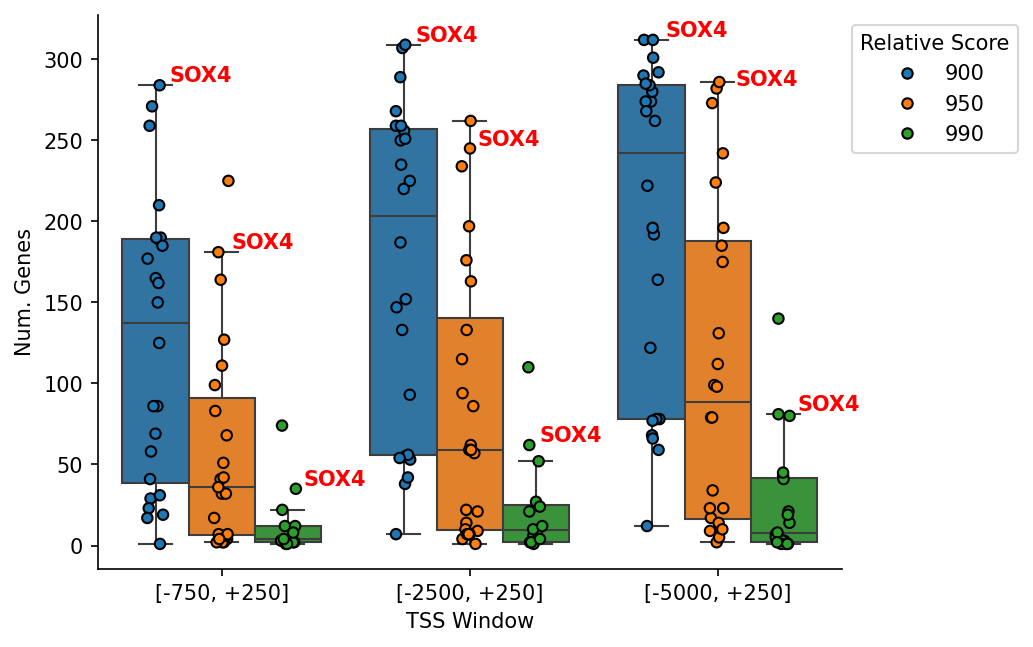

In [27]:
_=plt.figure(dpi=150)

# random seed to keep jitter the same for stripplot
np.random.seed(10)

_=sns.boxplot(x="TSS Window", y="Target", data=tf_num_diff_genes_targetting, hue="Relative Score", legend=False,showfliers=False)
_=sns.stripplot(x="TSS Window", y="Target", data=tf_num_diff_genes_targetting, edgecolor="black", hue="Relative Score", linewidth=1, dodge=True)

plt.legend(bbox_to_anchor=(1,1), title="Relative Score")
_=plt.xlabel("TSS Window")
_=plt.ylabel("Num. Genes")


# custom list of where the points should go on x-axis
text_x_values = [-0.21, 0.04, 0.33, .78, 1.03, 1.28, 1.79, 2.07, 2.32]

for x_value, num_genes in zip(text_x_values, sox4_summary["Target"].to_list()): 
    
    _= plt.text(x_value, num_genes+2, "SOX4", color="red", fontweight='bold')

for pos in ['top', 'right']: 
    plt.gca().spines[pos].set_visible(False)

plt.savefig("../output/num_differential_genes_sox4_highlighted.png", dpi=200, bbox_inches = "tight")

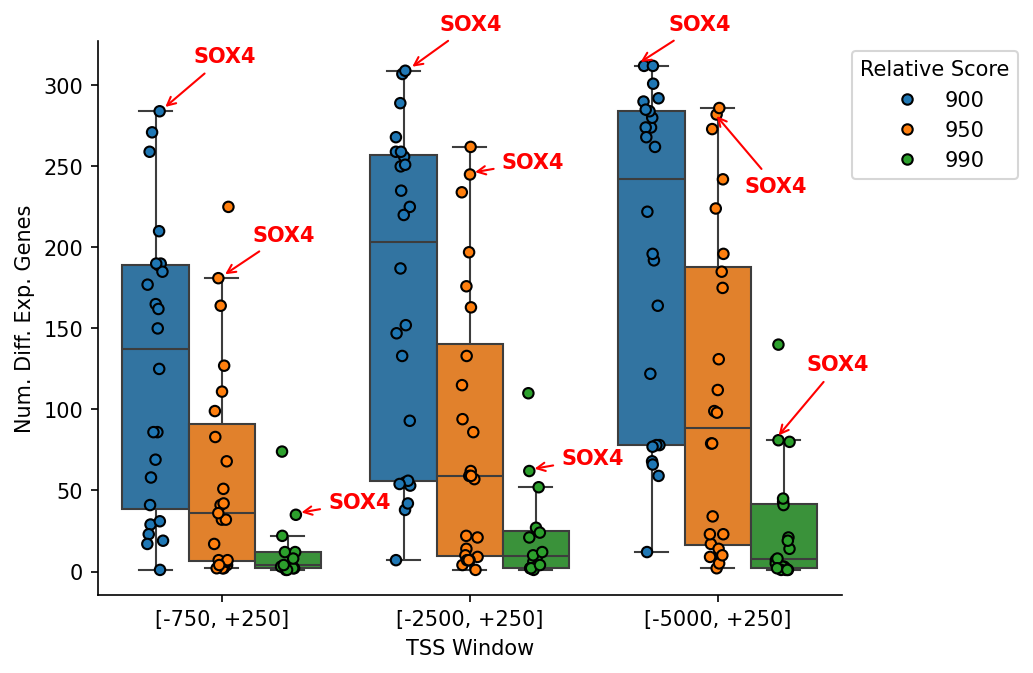

In [28]:
_=plt.figure(dpi=150)

# random seed to keep jitter the same for stripplot
np.random.seed(10)

_=sns.boxplot(x="TSS Window", y="Target", data=tf_num_diff_genes_targetting, hue="Relative Score", legend=False, showfliers=False)
_=sns.stripplot(x="TSS Window", y="Target", data=tf_num_diff_genes_targetting, edgecolor="black", hue="Relative Score", linewidth=1, dodge=True)

plt.legend(bbox_to_anchor=(1,1), title="Relative Score")
_=plt.xlabel("TSS Window")
_=plt.ylabel("Num. Diff. Exp. Genes")

# custom list of where the points should go on x-axis
text_x_values = [-0.235, 0.005, 0.31, .76, 1.01, 1.25, 1.68, 1.99, 2.24]

for x_value, num_genes in zip(text_x_values, sox4_summary["Target"].to_list()): 
    
    if x_value == 1.68:
        text_y_value = 330
    elif x_value == -0.235: 
        text_y_value = 310
    elif x_value == 0.005: 
        text_y_value = 200
    elif x_value == .76: 
        text_y_value = 330
    elif x_value == 1.99: 
        text_y_value = 230
    elif x_value == 2.24: 
        text_y_value = 120
    else: 
        text_y_value = num_genes
    
    _= plt.annotate(
        "SOX4", 
        xy=(x_value-0.005, num_genes+1), 
        xytext=(x_value + 0.12, text_y_value + 4), 
        arrowprops=dict(color='red', arrowstyle="->"), 
        color="red", 
        fontweight='bold'
    )

for pos in ['top', 'right']: 
    plt.gca().spines[pos].set_visible(False)

plt.savefig("../output/num_differential_genes_sox4_highlighted_arrow.png", dpi=200, bbox_inches="tight")

## Is `SOX4` Binding Overrepresented Amongst Differential Gene Expression?

#### Are all the genes considered in Sunny's analysis `protein-coding`?

The question changes from whether there's a correlation between differential expressed genes and `SOX4` binding to... 

Is there a correlation between PROTEIN CODING differential expressed genes and `SOX4` binding

In [29]:
# get the genes that are not protein coding from Sunny's analysis
non_protein_coding_sunny = set(sunny_diff_exp["ENSMUSG"].to_list())  - set(pd.read_csv("../../../../inputs/mouse_transcripts_genes_mapping/mm10_genes_and_transcripts.tsv", sep="\t")["Gene stable ID"].tolist())
non_protein_coding_sunny = list(non_protein_coding_sunny)

non_protein_coding_sunny

['ENSMUSG00000085133',
 'ENSMUSG00000110411',
 'ENSMUSG00000092274',
 'ENSMUSG00000101609',
 'ENSMUSG00000111521',
 'ENSMUSG00000078247',
 'ENSMUSG00000097652',
 'ENSMUSG00000089706',
 'ENSMUSG00000104621',
 'ENSMUSG00000104871',
 'ENSMUSG00000085148',
 'ENSMUSG00000054258',
 'ENSMUSG00000106386',
 'ENSMUSG00000087579',
 'ENSMUSG00000087365',
 'ENSMUSG00000110148',
 'ENSMUSG00000104814',
 'ENSMUSG00000115610',
 'ENSMUSG00000035364',
 'ENSMUSG00000100510',
 'ENSMUSG00000097258',
 'ENSMUSG00000092341',
 'ENSMUSG00000104435',
 'ENSMUSG00000102959',
 'ENSMUSG00000085194',
 'ENSMUSG00000111394',
 'ENSMUSG00000081822']

In [30]:
sunny_diff_exp[sunny_diff_exp["ENSMUSG"].isin(non_protein_coding_sunny)].index.size
sunny_diff_exp.index.size

27

341

27/341 genes provided are non-protein-coding. 

We are going to go ahead and use the non-protein-coding genes. 

Visualization of `Fisher's Exact Test`

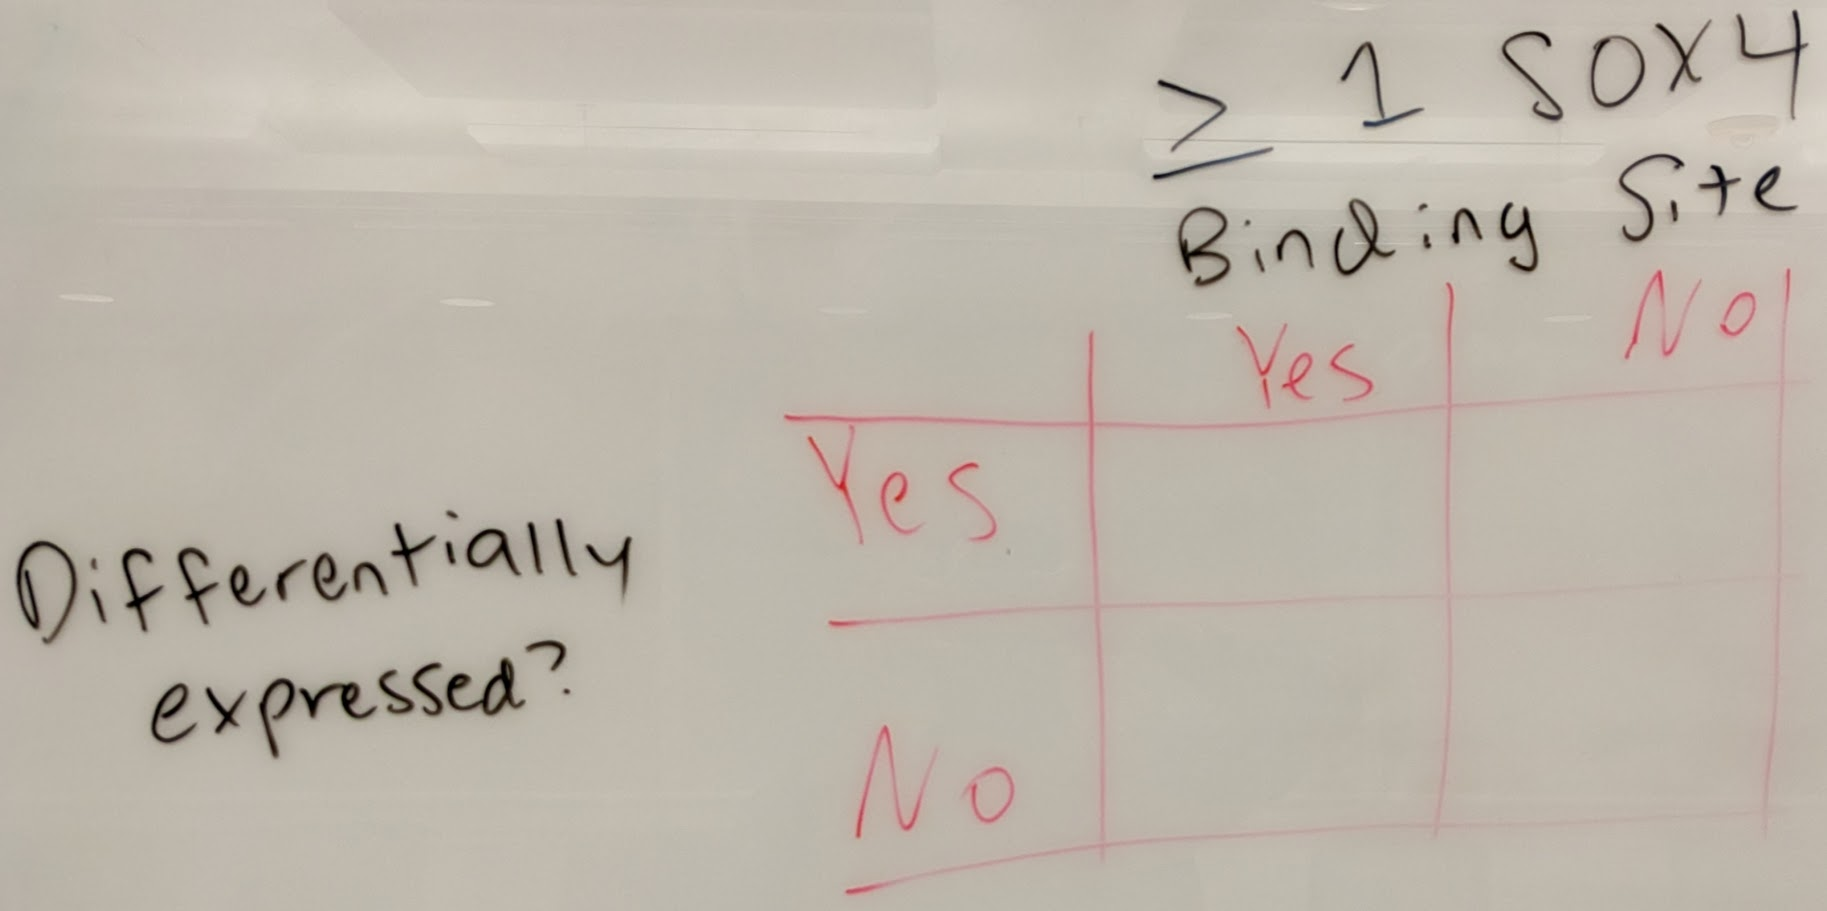

In [31]:
# get total protein coding genes 
num_protein_coding_genes = pd.read_csv("../../../../inputs/mouse_transcripts_genes_mapping/mm10_genes_and_transcripts.tsv", sep="\t")["Gene stable ID"].unique().size
num_protein_coding_genes

num_diff_protein_coding_genes = sunny_diff_exp[~sunny_diff_exp["ENSMUSG"].isin(non_protein_coding_sunny)].index.size
num_diff_protein_coding_genes

22287

314

In [32]:
# fisher's exact dataframe 
fisher_df = []

# run Fisher's exact test for each parameter combination 
for key in joined_final_edge_lists:
    
    diff_exp_edge_list = joined_final_edge_lists[key]
    # get sox4 targets that are diff expressed
    sox4_diff_exp = diff_exp_edge_list[diff_exp_edge_list["TF"]=="sox4"]["Target"].unique().size
    
    # sox4 targets that are not diff expressed
    # this works as this dict also uses same keys as above
    total_edge_list = final_edge_lists[key]
    # subtract sox4 differential expression 
    sox4_no_diff_exp = (total_edge_list[total_edge_list["TF"]=="sox4"]["Target"].unique().size) - sox4_diff_exp
    
    # take number of protein coding diff expressed genes and 
    # subtract by those that are sox4 targets 
    no_sox4_diff_exp = num_diff_protein_coding_genes - sox4_diff_exp

    # get all unique protein coding gene IDs and subtract that from differentially expressed genes  
    non_diff_exp_genes = (num_protein_coding_genes - num_diff_protein_coding_genes)
    
    # subtract non diff exp protein coding genes from the subset that still have sox4 binding sites
    no_sox4_no_diff_exp = non_diff_exp_genes - sox4_no_diff_exp
    
    # create contingency table
    contingency_table = [[sox4_diff_exp, no_sox4_diff_exp], [sox4_no_diff_exp, no_sox4_no_diff_exp]]
    contingency_table
    
    # run fishers exact test
    stats = scipy.stats.fisher_exact(contingency_table)
    
    # save results to dataframe
    fisher_df.append(
        pd.DataFrame([key, stats.statistic, stats.pvalue]).T
    )
    
fisher_df = pd.concat(fisher_df).astype({2: "float64"})
fisher_df.columns = ["Parameter Combination", "Odds Ratio", "Nominal P Value"]

fisher_df

fisher_df.to_csv("../output/sox4_fishers_exact_test.tsv", sep="\t", index=False)

[[284, 30], [17063, 4910]]

[[309, 5], [19069, 2904]]

[[312, 2], [19240, 2733]]

[[181, 133], [9988, 11985]]

[[245, 69], [15224, 6749]]

[[282, 32], [17536, 4437]]

[[35, 279], [1008, 20965]]

[[62, 252], [2108, 19865]]

[[81, 233], [3280, 18693]]

,Parameter Combination,Odds Ratio,Nominal P Value
0,upstream_750_score_900,2.724101,5.984445e-09
0,upstream_2500_score_900,9.411464,2.919318e-13
0,upstream_5000_score_900,22.159459,2.390933e-15
0,upstream_750_score_950,1.633001,1.771933e-05
0,upstream_2500_score_950,1.574083,6.765072e-04
0,upstream_5000_score_950,2.229759,3.320685e-06
0,upstream_750_score_990,2.609145,2.199238e-06
0,upstream_2500_score_990,2.318511,7.309915e-08
0,upstream_5000_score_990,1.981227,6.551972e-07


#### Initialize differential expression `TF` networks

In [33]:
differential_expression_tf_networks = {}

# create directed NetworkX graphs specifying source and target 

for key in joined_final_edge_lists: 
    tmp = nx.from_pandas_edgelist(joined_final_edge_lists[key], source="TF", target="Target", create_using=nx.DiGraph())
    differential_expression_tf_networks[key] = tmp
    
#     plt.figure(dpi=300)
#     plt.title(key)
#     nx.draw(tmp, pos= nx.spring_layout(tmp))
#     plt.show()

## Output Networks in Pickled Format

In [34]:
for key in differential_expression_tf_networks: 
    
    pickle.dump(
        differential_expression_tf_networks[key],
        open(
            "../../../../outputs/pickled_networks/differential_expression_tf_networks/{}.networkx_graph".format(key), 
            'wb'
        )
    )

In [35]:
for key in tf_tf_networks: 
    
    pickle.dump(
        
        tf_tf_networks[key],
        open(
            "../../../../outputs/pickled_networks/tf_tf_networks/{}.networkx_graph".format(key), 
            'wb'
        )
        
    )